<a href="https://colab.research.google.com/github/sascott9655/ADS-504-Machine-Learning/blob/main/Sample_Code_HW_Assignment_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# These IMPORTs will be needed :)

import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.preprocessing import OrdinalEncoder
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

**Load and understand  Data**

Animal shelter data set



In [3]:
data = pd.read_csv('/content/sample_data/shelter_data.csv')  #Read the data here
data.describe()

,AnimalID,Name,DateTime,OutcomeType,OutcomeSubtype,AnimalType,SexuponOutcome,AgeuponOutcome,Breed,Color
count,26729,19038,26729,26729,13117,26729,26728,26711,26729,26729
unique,26729,6374,22918,5,16,2,5,44,1380,366
top,A706629,Max,2015-08-11 00:00:00,Adoption,Partner,Dog,Neutered Male,1 year,Domestic Shorthair Mix,Black/White
freq,1,136,19,10769,7816,15595,9779,3969,8810,2824


In [4]:
data.head()

,AnimalID,Name,DateTime,OutcomeType,OutcomeSubtype,AnimalType,SexuponOutcome,AgeuponOutcome,Breed,Color
0,A671945,Hambone,2014-02-12 18:22:00,Return_to_owner,NaN,Dog,Neutered Male,1 year,Shetland Sheepdog Mix,Brown/White
1,A656520,Emily,2013-10-13 12:44:00,Euthanasia,Suffering,Cat,Spayed Female,1 year,Domestic Shorthair Mix,Cream Tabby
2,A686464,Pearce,2015-01-31 12:28:00,Adoption,Foster,Dog,Neutered Male,2 years,Pit Bull Mix,Blue/White
3,A683430,NaN,2014-07-11 19:09:00,Transfer,Partner,Cat,Intact Male,3 weeks,Domestic Shorthair Mix,Blue Cream
4,A667013,NaN,2013-11-15 12:52:00,Transfer,Partner,Dog,Neutered Male,2 years,Lhasa Apso/Miniature Poodle,Tan


In [23]:
# this line drops any rows with missing data
cleaned_data = data.dropna()
# here we grab the data we want from pandas
X_data = cleaned_data[['AnimalType','SexuponOutcome','AgeuponOutcome']]
y_data = cleaned_data[['OutcomeType']]
#print(X_data['AgeuponOutcome'].value_counts())
enc = OrdinalEncoder()
enc.fit(X_data)
le = preprocessing.LabelEncoder()
le.fit(y_data)
data_categorical = pd.DataFrame(enc.transform(X_data),
columns=list(X_data))
X=data_categorical
y=le.transform(y_data)
# Without changing the random state, divide your data into 50% for test and 50% for train
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [24]:
#Apply the model here
clf = tree.DecisionTreeClassifier()  #Create your model here
short_tree = clf.fit(X_train, y_train)   #Fit on training data
y_pred = clf.predict(X_test)
print('accuracy %2.2f ' % accuracy_score(y_test,y_pred))

accuracy 0.73 


In [25]:
# Let's see the confusion matrix together
cm_clf = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred))
labels=['Adoption', 'Died', 'Euthanasia', 'Transfer']
test_results = pd.DataFrame(cm_clf,index=labels,columns=labels)
display(test_results)

,Adoption,Died,Euthanasia,Transfer
Adoption,229,0,9,204
Died,1,0,1,13
Euthanasia,2,0,22,160
Transfer,59,0,26,1019


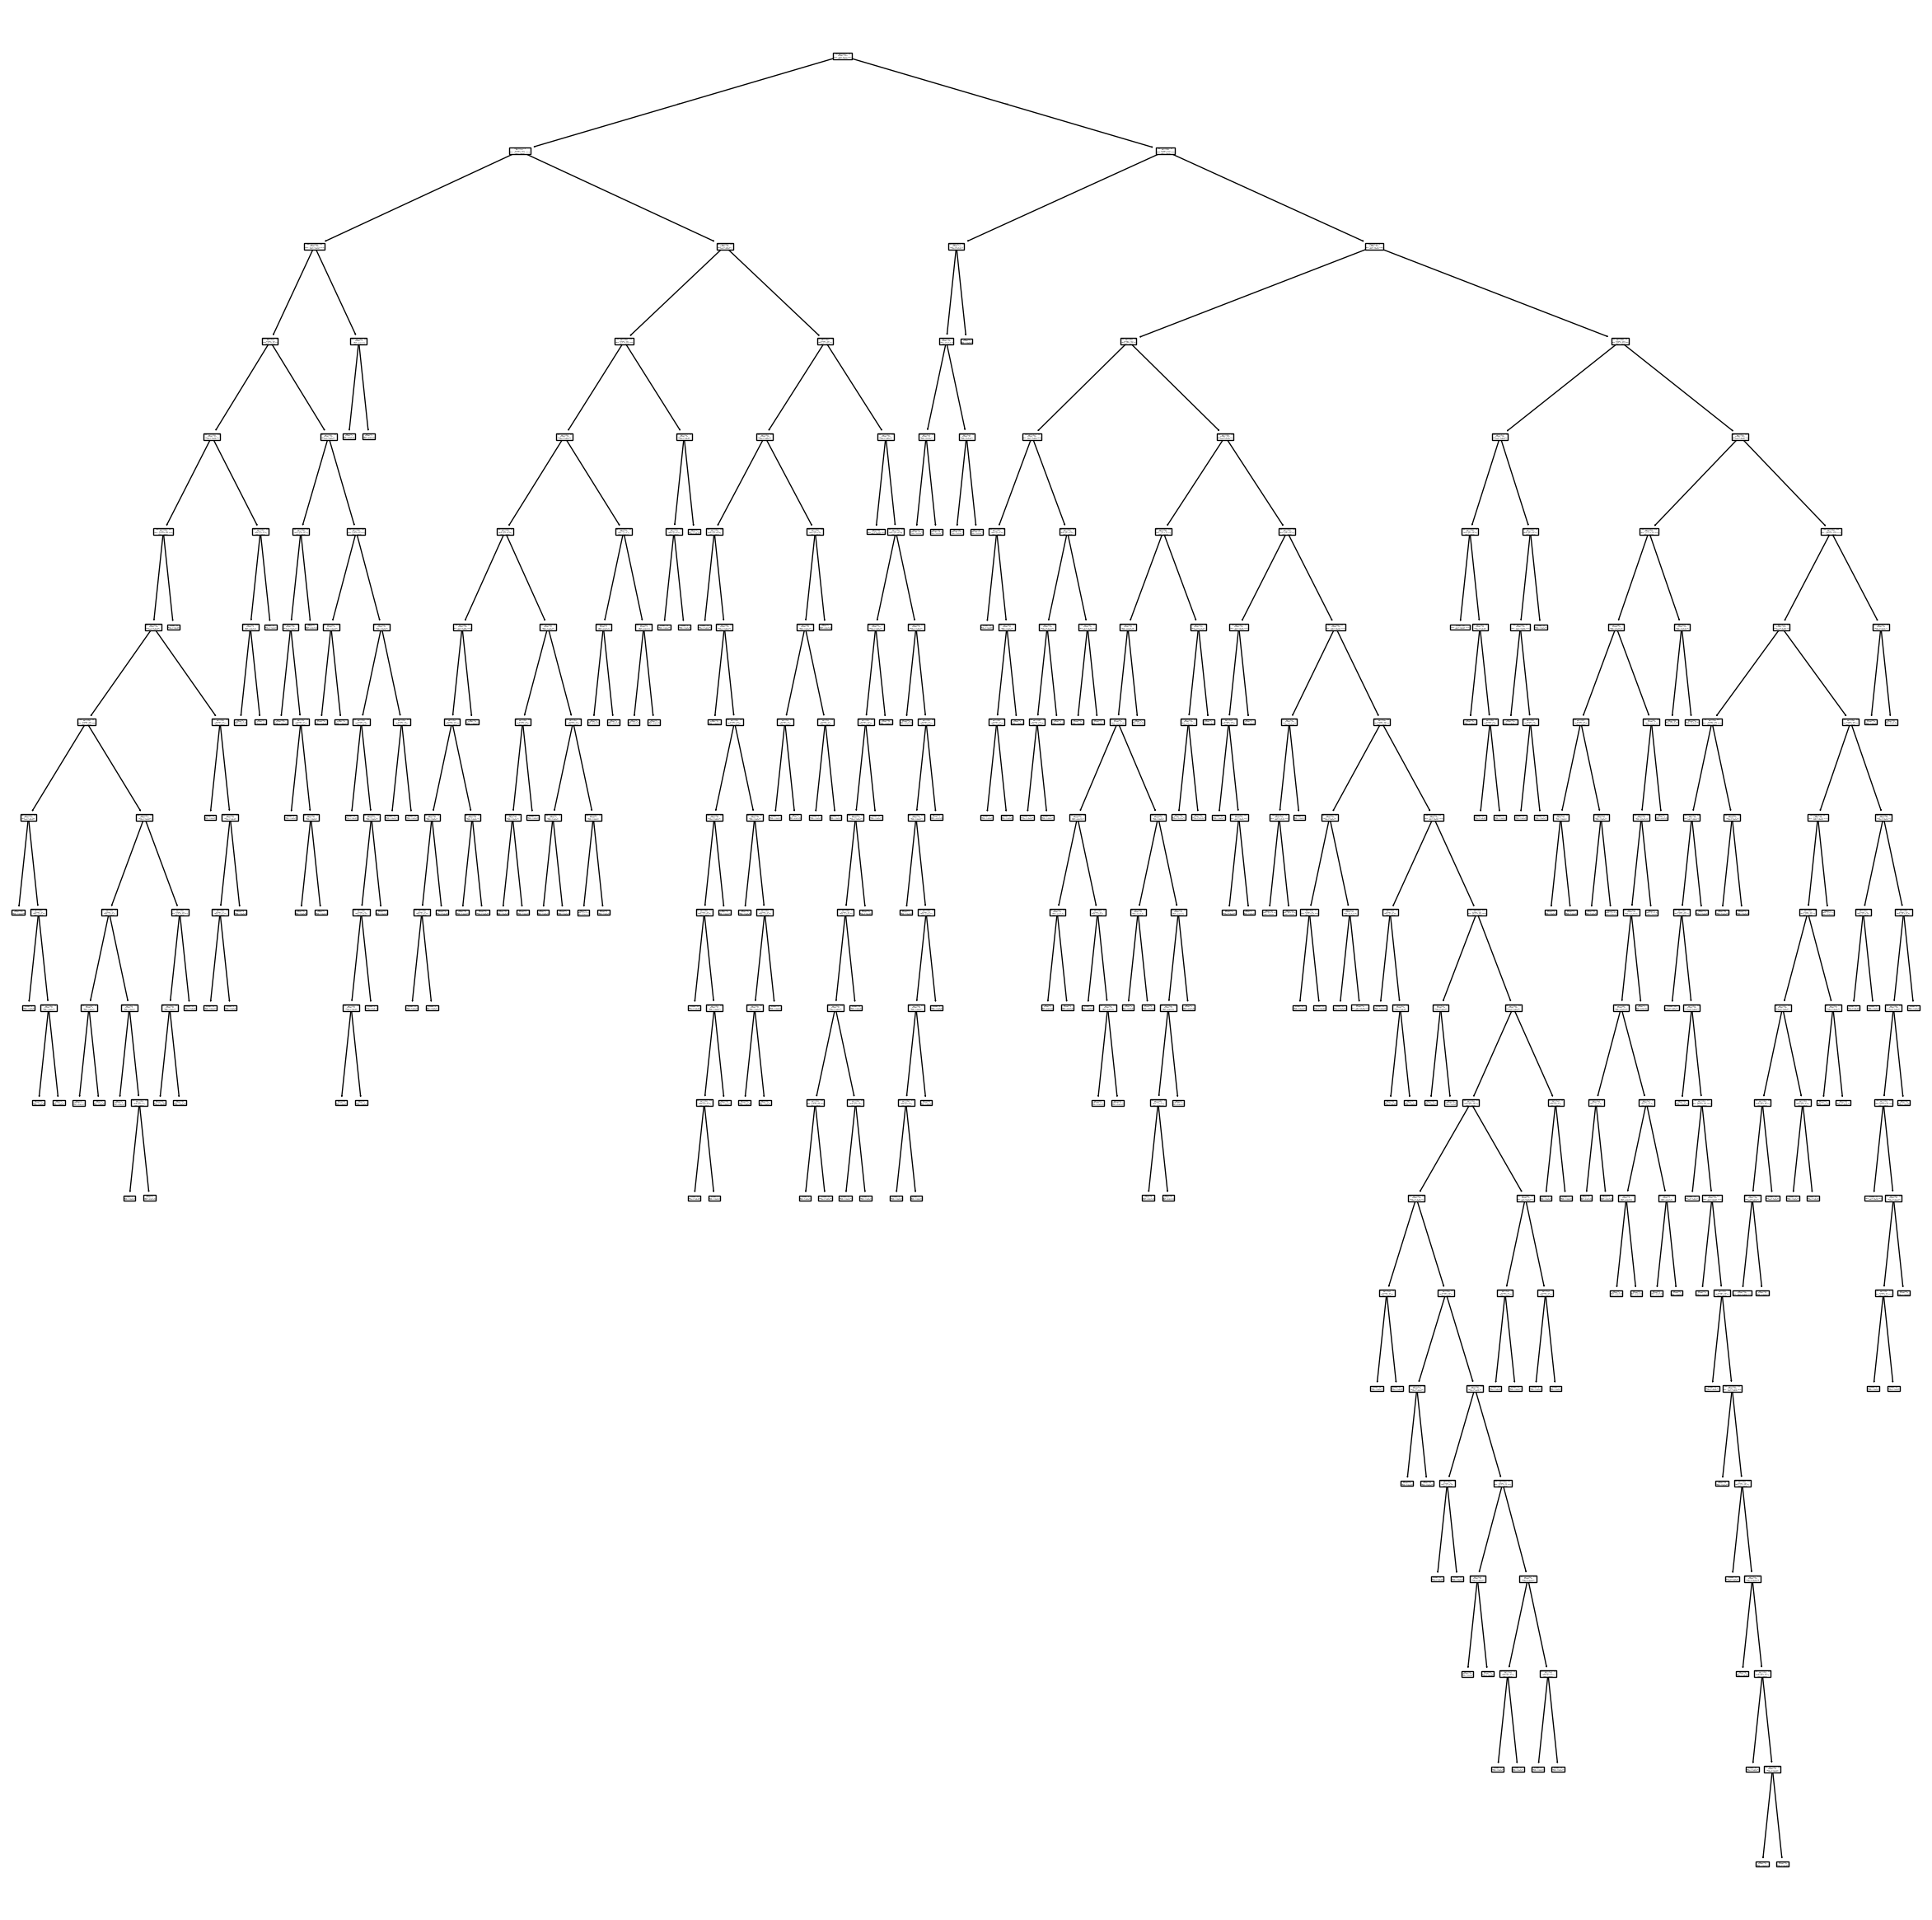

In [26]:
# Plot the decision tree
fig,ax = plt.subplots(figsize = (30,30))
treeplot = tree.plot_tree(clf, feature_names=['AnimalType','SexuponOutcome','AgeuponOutcome'],
class_names = ['Adoption', 'Died', 'Euthanasia', 'Transfer'],ax=ax)


**Problem 2.1. Animal Control**

In [27]:
# Train a new decision tree here! Remember this time maxdepth should be 3 (short tree)
#Apply the model here
short_tree = tree.DecisionTreeClassifier(max_depth=3)  #Create your model here
short_tree = short_tree.fit(X_train, y_train)   #Fit on training data
y_pred = short_tree.predict(X_test)
print('accuracy %2.2f ' % accuracy_score(y_test,y_pred))

accuracy 0.65 


In [28]:
# Create confusion matrix
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred))
labels=['Adoption', 'Died', 'Euthanasia', 'Transfer']
test_results = pd.DataFrame(cm,index=labels,columns=labels)
display(test_results)

,Adoption,Died,Euthanasia,Transfer
Adoption,31,0,0,411
Died,0,0,0,15
Euthanasia,0,0,0,184
Transfer,0,0,1,1103


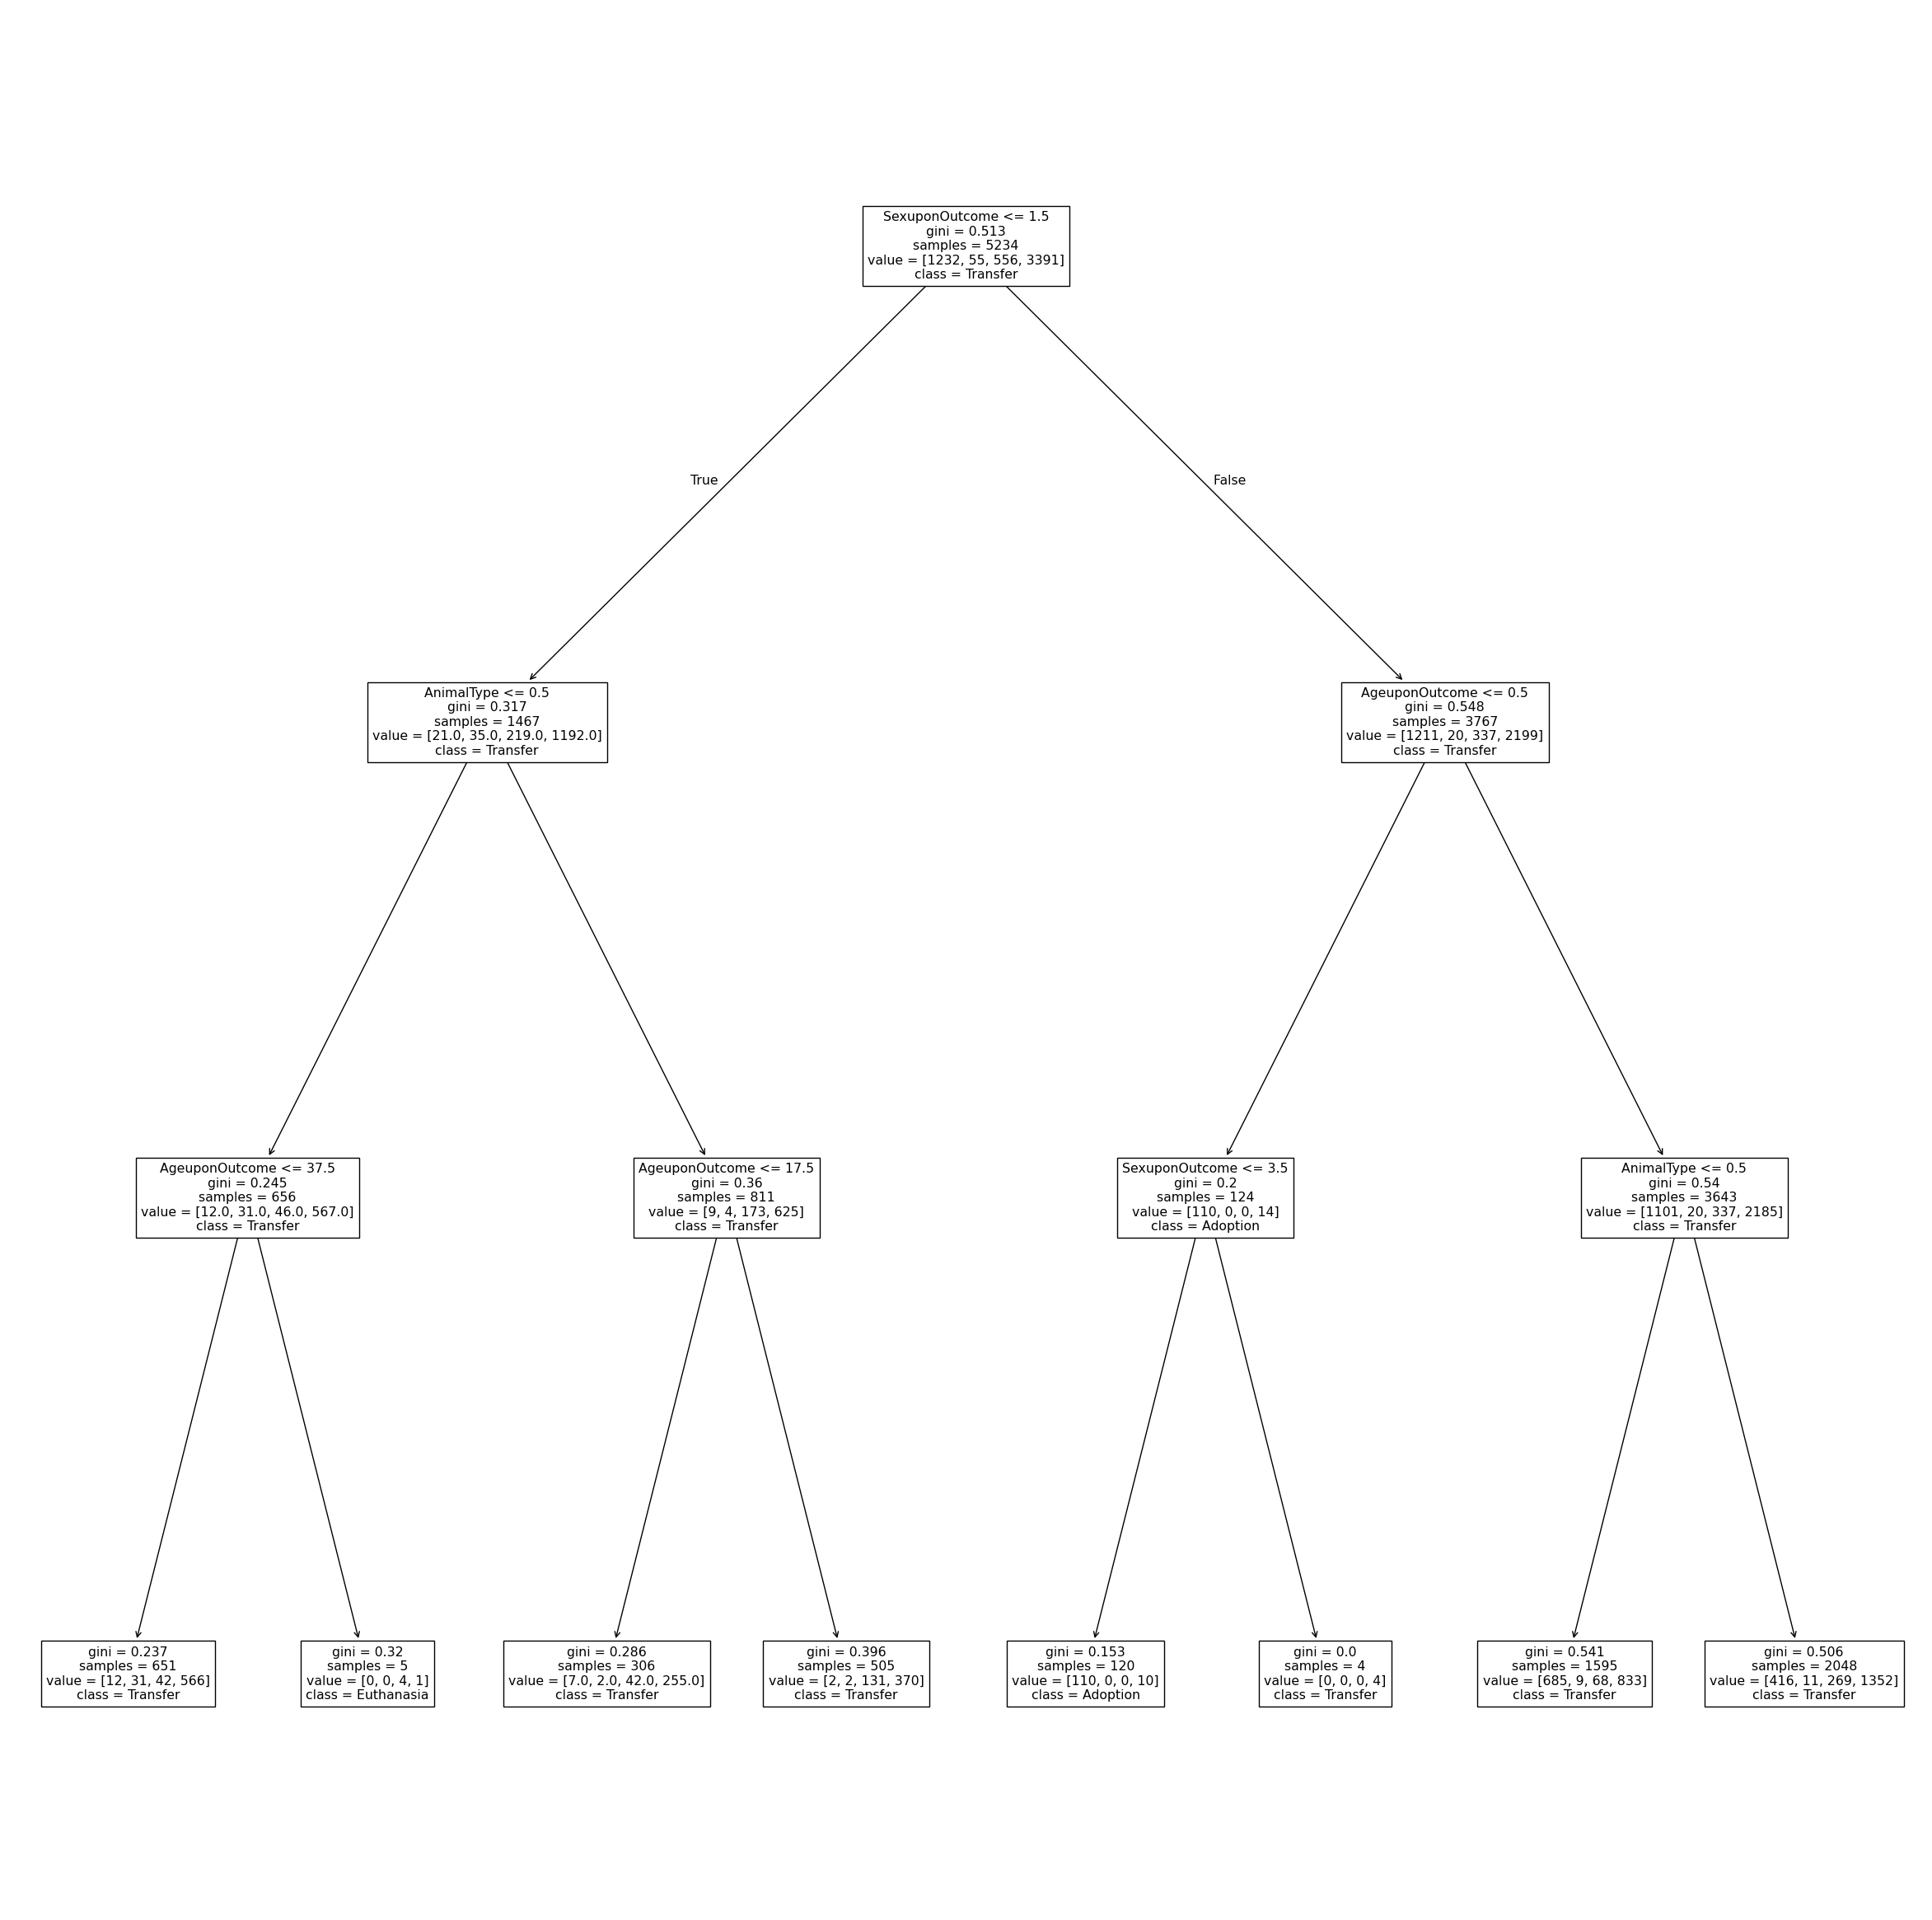

In [29]:
# Plot the tree here
fig,ax = plt.subplots(figsize = (30,30))
treeplot = tree.plot_tree(short_tree, feature_names=['AnimalType','SexuponOutcome','AgeuponOutcome'],
class_names = ['Adoption', 'Died', 'Euthanasia', 'Transfer'],ax=ax)

**Varying Tree Depth using Loop**

In [ ]:
train_errors = list()
test_errors = list()
for x in range(3,11):
  #Create multiple models here each based on the x variable above
  # Store the result of modes in train_erors and test_errors variables

# Plot of test and training erros
plt.plot(range(3,11),train_errors, label='Train')
plt.plot(range(3,11),test_errors, label='Test')
plt.legend(loc='upper left')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')

*Your conclusion about above graph comes here*


**Tree Pruning here**

In [ ]:
tree_prune =
tree_prune =
treeplot = tree.plot_tree(tree_prune, feature_names=['AnimalType','SexuponOutcome','AgeuponOutcome'],
class_names = ['Adoption', 'Died', 'Euthanasia', 'Transfer'],ax=ax)

**Pruned Accuracy vs. Unpruned**

In [ ]:
y_pred4 = tree_prune.predict(X_test)
print('accuracy %2.2f ' % accuracy_score(y_test,y_pred4))
# Type here your understanding about this comparison


In [ ]:
# Create two confusion matrices here. The first confusion matrix shows predictions for the pruned tree and the second one
# predictions for the unpruned one

**Text Data**

In [ ]:
text_data = pd.read_csv() # Read data remember (meta_author will be the target)

In [ ]:
# Create the decision tree here Randomstate=42 90% training and 10% testing
X=
le = preprocessing.LabelEncoder()
labels = text_data['meta_author']
le.fit(labels)
y=le.transform(labels)


**Problem 2.2**

In [ ]:
#Create a loop of max depth from 1 to 16 similar to previous step and draw the
#above mentioned graph

In [ ]:
# With a simple code, you can see the frequency of the words
text_frequecies = X.sum()
text_frequecies.sort_values()
display(text_frequecies)
kept_words = text_frequecies[text_frequecies<2]
# this line (above) first creates a binary vector for each word, telling us if it appears twice or more
# in the dataset. it then uses that vector to index into text_frequencies to subset only the data
# for which this binary vector evaluates to TRUE. This simple indexing can really help to chop through
# a huge pandas dataframe.
print(kept_words)
small_vocab_X= X [kept_words.index]
# notice how kept_words.index is a list of strings, the same you can use to access the headers of X..

In [ ]:
# Now repeat the previous analysis (design model by changing the model depth
#from 1 to 16) with smaller word dataset small_vocab_X
# Plot the above graph again

**Most frequent words**




In [ ]:
# Same as before create the most frequent words
kept_words2 = text_frequecies[text_frequecies>100]
# this line (above) first creates a binary vector for each word, telling us if it appears twice or more
# in the dataset. it then uses that vector to index into text_frequencies to subset only the data
# for which this binary vector evaluates to TRUE. This simple indexing can really help to chop through
# a huge pandas dataframe.
print(kept_words2)
large_vocab_X= X [kept_words2.index]

In [ ]:
# Now repeat the previous analysis (design model by changing the model depth
#from 1 to 16) with smaller word dataset large_vocab_X
# Plot the above graph again

In [ ]:
# Explain your understanding from the graph

**Audio Data**

In [ ]:
audio_data = pd.read_csv(). # This time you should drop two columns first: filename and label

In [ ]:
# Desing Decision tree here 80% training 20% testing

**Problem 2.3**

In [ ]:
# Now repeat the previous analysis (design model by changing the model depth
#from 1 to 16)
# Plot the above graph again

In [ ]:
# Draw the decision tree plot with max_depth=5

**Dropping a training example from data**

In [ ]:
X_dropped = X.drop(1)
y= pd.Series(y)
y_drop = y.drop(1)
X_train, X_test, y_train, y_test =   #80% training

In [ ]:
sound_tree2 = # model with max_depth = 5
sound_tree2 =
plt.subplot(1, 2, 1)
treeplot = tree.plot_tree()
plt.title("Before")
plt.subplot(1, 2, 2)
treeplot2 = tree.plot_tree(sound_tree2)
plt.title("After")
plt.show()

In [ ]:
X = audio_data.drop('label_text',axis=1)
# Create data with 50% for training. You need to use one hot encodr

In [ ]:
# Now repeat the previous analysis (design model by changing the model depth
#from 1 to 16)
# Plot the above graph again

**Bad Classifiers**

In [ ]:
class BadClassifier():
  def __init__(self):
    pd = __import__('pandas')
    self.label_counts = pd.Series()
  def train(self, y_train):
    train_labels = pd.Series(y_train)
    label_counts = train_labels.value_counts(normalize=True)
    self.label_counts = label_counts.sort_index()
  def make_random_predictions(self, X_test):
    pred_labels=[]
    test_labels = pd.Series(y_test)
    test_label_counts = np.random.multinomial(X_test.shape[0],self.label_counts.values)
    for count,label in zip (test_label_counts,self.label_counts.index.values):
      pred_labels = pred_labels + [label for x in range(0,count)]
    np.random.shuffle(pred_labels)
    return pred_labels

In [ ]:
bad = BadClassifier()
accuracy = list()
train_errors = list()
test_errors = list()
for x in range(1,16):
  bad.train(y_train)
  y_pred = bad.make_random_predictions(X_test)
  accuracy.append()   # Fill this
  sound_trees =  # Fill this
  sound_trees = # Fill this
  train_errors.append()# Fill this
  test_errors.append()# Fill this
# plotting
plt.plot(range(1,16),accuracy, label='Random')
plt.plot(range(1,16),train_errors, label='Train')
plt.plot(range(1,16),test_errors, label='Test')
plt.legend(loc='center right')
plt.xlabel('Depth parameter')
plt.ylabel('Performance')


In [ ]:
# Repeat above step but this time use only 1% of data for testing